In [1]:
import os
import hopsworks
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# 1. Load your API key
load_dotenv()
api_key = os.getenv("HopsworkAPI_KEY")

project = hopsworks.login(api_key_value=api_key)

fs = project.get_feature_store()

fg = fs.get_feature_group("sialkot_aqi_features_v2", version=1)
df = fg.read()

print(f"Total rows downloaded: {len(df)}")

2026-06-04 22:43:47,890 INFO: Initializing external client
2026-06-04 22:43:47,890 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-06-04 22:43:51,981 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32895
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (5.92s) 
Total rows downloaded: 2689


In [2]:
df.head(15)

,datetime,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,aqi,co,no2,o3,so2,pm2_5,pm10,nh3,date,hour,city
0,2026-02-01 00:00:00,0.6,0.0,9.3,2.5,0.00,100,5,2435.33,24.59,4.33,1.30,346.10,375.74,5.82,2026-02-01,0,Sialkot
1,2026-02-01 01:00:00,8.6,0.0,9.4,10.8,0.04,97,5,2413.72,23.49,3.61,1.26,353.64,377.72,12.67,2026-02-01,1,Sialkot
2,2026-02-01 02:00:00,3.3,0.0,8.4,9.0,0.00,100,5,2466.80,23.53,2.63,1.66,365.58,389.49,15.17,2026-02-01,2,Sialkot
3,2026-02-01 03:00:00,5.2,0.0,9.4,10.1,0.04,97,5,2593.56,24.47,2.44,2.10,379.25,404.59,15.36,2026-02-01,3,Sialkot
4,2026-02-01 04:00:00,7.4,0.0,12.4,10.8,0.12,92,5,2658.71,22.94,8.73,2.35,382.61,412.41,14.31,2026-02-01,4,Sialkot
5,2026-02-01 05:00:00,9.6,0.0,14.8,13.3,0.33,80,5,2612.46,21.51,22.83,2.66,378.08,413.17,16.70,2026-02-01,5,Sialkot
6,2026-02-01 06:00:00,5.2,0.0,15.8,19.8,0.52,72,5,2537.78,20.88,53.49,3.07,380.16,416.14,22.43,2026-02-01,6,Sialkot
7,2026-02-01 07:00:00,5.4,0.0,16.7,15.5,0.70,64,5,843.28,5.51,151.99,9.36,149.55,161.54,4.34,2026-02-01,7,Sialkot
8,2026-02-01 08:00:00,2.2,0.0,17.5,15.5,0.78,61,5,626.73,3.41,155.87,9.08,112.20,122.13,4.27,2026-02-01,8,Sialkot
9,2026-02-01 09:00:00,1.7,0.0,17.5,12.6,0.80,60,5,613.02,3.14,158.94,9.48,109.84,119.67,5.06,2026-02-01,9,Sialkot


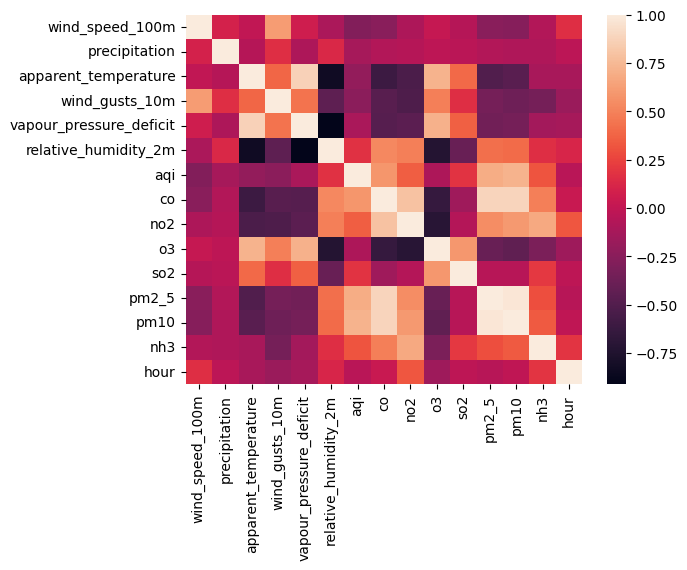

In [3]:
import seaborn as sns

data = df.corr(numeric_only=True)

# Create the heatmap
sns.heatmap(data)
plt.show()


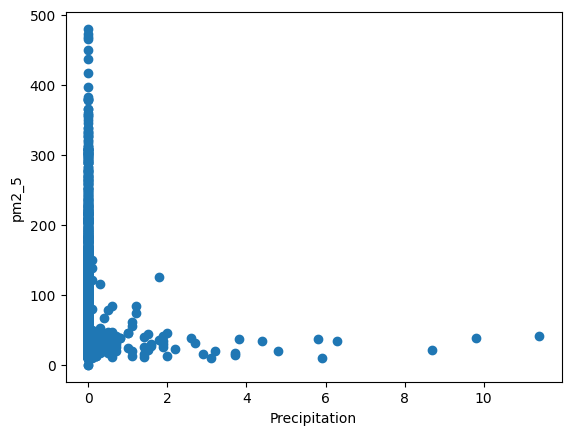

In [4]:
x = df['precipitation']
y = df['pm2_5']
plt.scatter(x,y)
plt.xlabel('Precipitation')
plt.ylabel('pm2_5')
plt.show()

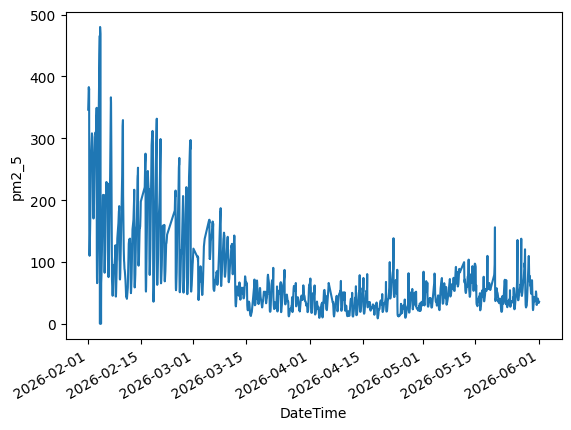

In [5]:
x = df['datetime']
y = df['pm2_5']
plt.plot(x,y)
plt.xlabel('DateTime')
plt.ylabel('pm2_5')
# This automatically rotates and formats the dates so they don't overlap!
plt.gcf().autofmt_xdate()
plt.show()